In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv('PC_Gamer_test.csv', sep=';')
print(df.tail(10))
print(df.shape)

           Item                  Descricao   Preco        Data
63      Headset          BINNUNE Bluetooth  107.59  2026-08-01
64     Soundbar                    NIYE V8   93.01  2026-08-01
65          CPU         AMD Ryzen 5 5600GT  989.99  2026-08-10
66  Motherboard           Chronos B550M-CR  611.75  2026-08-10
67          SSD       Husky ssd nvme 512GB  794.30  2026-08-10
68     Gabinete            C3tech Aquarius  289.70  2026-08-10
69        Mouse  Attack Shark Wireless X11  127.29  2026-08-10
70      Headset          BINNUNE Bluetooth  108.29  2026-08-10
71     Soundbar                    NIYE V8   95.77  2026-08-10
72      Teclado      M96 teclado bluetooth  189.07  2026-08-16
(73, 4)


## Cálculo das médias

In [20]:
medias = df.groupby('Item')['Preco'].mean()

media_cpu = medias['CPU']
media_motherboard = medias['Motherboard']
media_ssd = medias['SSD']
#media_ram = medias['RAM']
media_keyboard = medias['Teclado']
media_gabinete = medias['Gabinete']
media_mouse = medias['Mouse']
media_headset = medias['Headset']
media_soundbar = medias['Soundbar']


print("Valores médios:")
print(f"media_cpu         = R$ {media_cpu:.2f}")
print(f"media_motherboard = R$ {media_motherboard:.2f}")
print(f"media_ssd         = R$ {media_ssd:.2f}")
#print(f"media_ram        = R$ {media_ram:.2f}")
print(f"media_teclado     = R$ {media_keyboard:.2f}")
print(f"media_gabinete    = R$ {media_gabinete:.2f}")
print(f"media_mouse       = R$ {media_mouse:.2f}")
print(f"media_headset     = R$ {media_headset:.2f}")
print(f"media_soundbar    = R$ {media_soundbar:.2f}")

Valores médios:
media_cpu         = R$ 1013.67
media_motherboard = R$ 640.63
media_ssd         = R$ 1111.43
media_teclado     = R$ 189.07
media_gabinete    = R$ 293.39
media_mouse       = R$ 132.58
media_headset     = R$ 109.55
media_soundbar    = R$ 100.19


In [21]:
itens = df.groupby('Item')

# Armazenar em dicionário
df_itens = {item: group.copy() for item, group in itens}

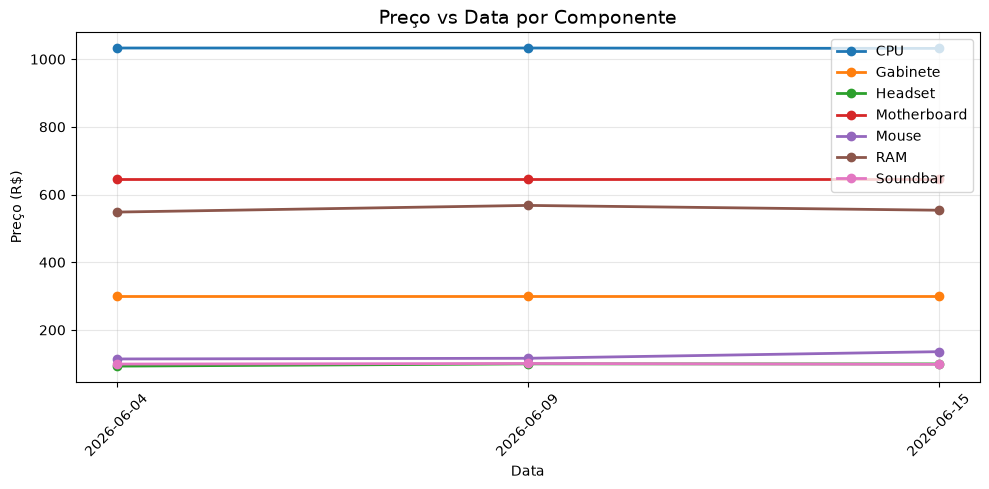

In [8]:
# Plotar todos no mesmo gráfico
plt.figure(figsize=(10, 5))

for item, df_item in df_itens.items():
    plt.plot(df_item['Data'], df_item['Preco'], marker='o', label=item, linewidth=2)

plt.title('Preço vs Data por Componente', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Preço (R$)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
import seaborn as sns
from datetime import datetime

In [23]:
# Configurar estilo dos gráficos
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [24]:
# 1. Ler o arquivo CSV
df = pd.read_csv('PC_Gamer_test.csv', sep=';', encoding='utf-8-sig', parse_dates=['Data'])

print("Dados carregados:")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"Tipos de item únicos: {df['Item'].unique()}")

Dados carregados:
          Item                  Descricao    Preco       Data
0          CPU         AMD Ryzen 5 5600GT  1032.93 2026-06-04
1  Motherboard           Chronos B550M-CR   647.05 2026-06-04
2     Gabinete            C3tech Aquarius   299.83 2026-06-04
3        Mouse  Attack Shark Wireless X11   114.29 2026-06-04
4      Headset          BINNUNE Bluetooth    93.11 2026-06-04

Shape: (73, 4)
Tipos de item únicos: <StringArray>
[        'CPU', 'Motherboard',    'Gabinete',       'Mouse',     'Headset',
    'Soundbar',         'SSD',     'Teclado']
Length: 8, dtype: str


In [25]:
# 2. Agrupar por Item e armazenar em variáveis
# Criar um dicionário para armazenar os DataFrames de cada item
df_itens = {}

for item in df['Item'].unique():
    df_itens[item] = df[df['Item'] == item].copy()
    df_itens[item] = df_itens[item].sort_values('Data')  # Ordenar por data
    print(f"\n{item}: {len(df_itens[item])} registros")
    print(df_itens[item][['Data', 'Preco']].to_string(index=False))


CPU: 11 registros
      Data   Preco
2026-06-04 1032.93
2026-06-09 1032.93
2026-06-15 1031.76
2026-06-21 1031.76
2026-06-28 1000.15
2026-07-05 1009.58
2026-07-12  995.08
2026-07-17 1022.78
2026-07-27 1003.46
2026-08-01  999.90
2026-08-10  989.99

Motherboard: 11 registros
      Data  Preco
2026-06-04 647.05
2026-06-09 647.05
2026-06-15 647.05
2026-06-21 647.05
2026-06-28 647.05
2026-07-05 647.05
2026-07-12 647.05
2026-07-17 647.05
2026-07-27 647.05
2026-08-01 611.75
2026-08-10 611.75

Gabinete: 11 registros
      Data  Preco
2026-06-04 299.83
2026-06-09 299.83
2026-06-15 299.83
2026-06-21 299.83
2026-06-28 289.72
2026-07-05 289.72
2026-07-12 289.72
2026-07-17 289.72
2026-07-27 289.72
2026-08-01 289.72
2026-08-10 289.70

Mouse: 11 registros
      Data  Preco
2026-06-04 114.29
2026-06-09 116.30
2026-06-15 135.81
2026-06-21 154.99
2026-06-28 136.13
2026-07-05 127.97
2026-07-12 140.23
2026-07-17 139.06
2026-07-27 139.78
2026-08-01 126.58
2026-08-10 127.29

Headset: 11 registros
      Data

In [26]:
# Acessar cada item individualmente (se preferir variáveis separadas)
cpu_df = df_itens['CPU']
motherboard_df = df_itens['Motherboard']
#ram_df = df_itens['RAM']
keyboard_df = df_itens['Teclado']
gabinete_df = df_itens['Gabinete']
mouse_df = df_itens['Mouse']
headset_df = df_itens['Headset']
soundbar_df = df_itens['Soundbar']

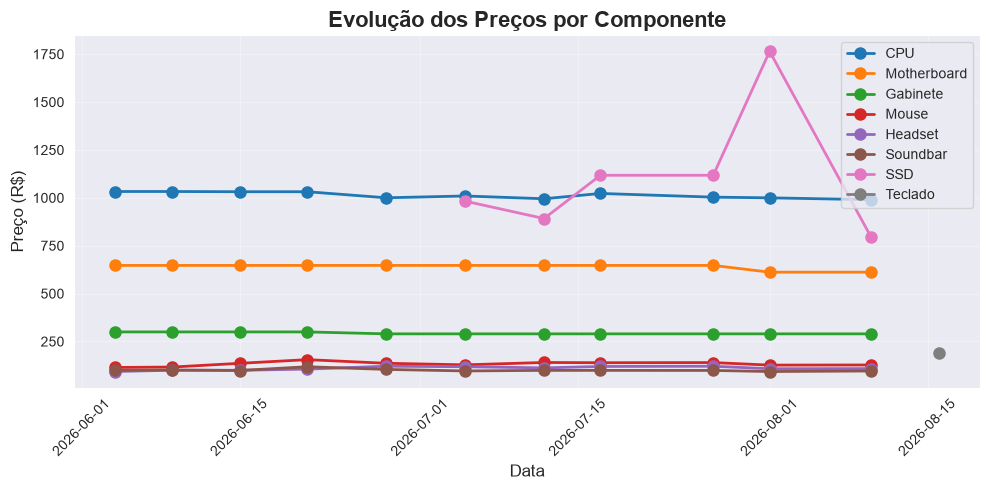

In [27]:
# 3. Plotar gráfico: Preço vs Data para cada tipo de item

# Opção 1: Todos os itens no mesmo gráfico (recomendado para comparação)
plt.figure(figsize=(10, 5))

for item, df_item in df_itens.items():
    plt.plot(df_item['Data'], df_item['Preco'], 
             marker='o', 
             label=item, 
             linewidth=2, 
             markersize=8)

plt.title('Evolução dos Preços por Componente', fontsize=16, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço (R$)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

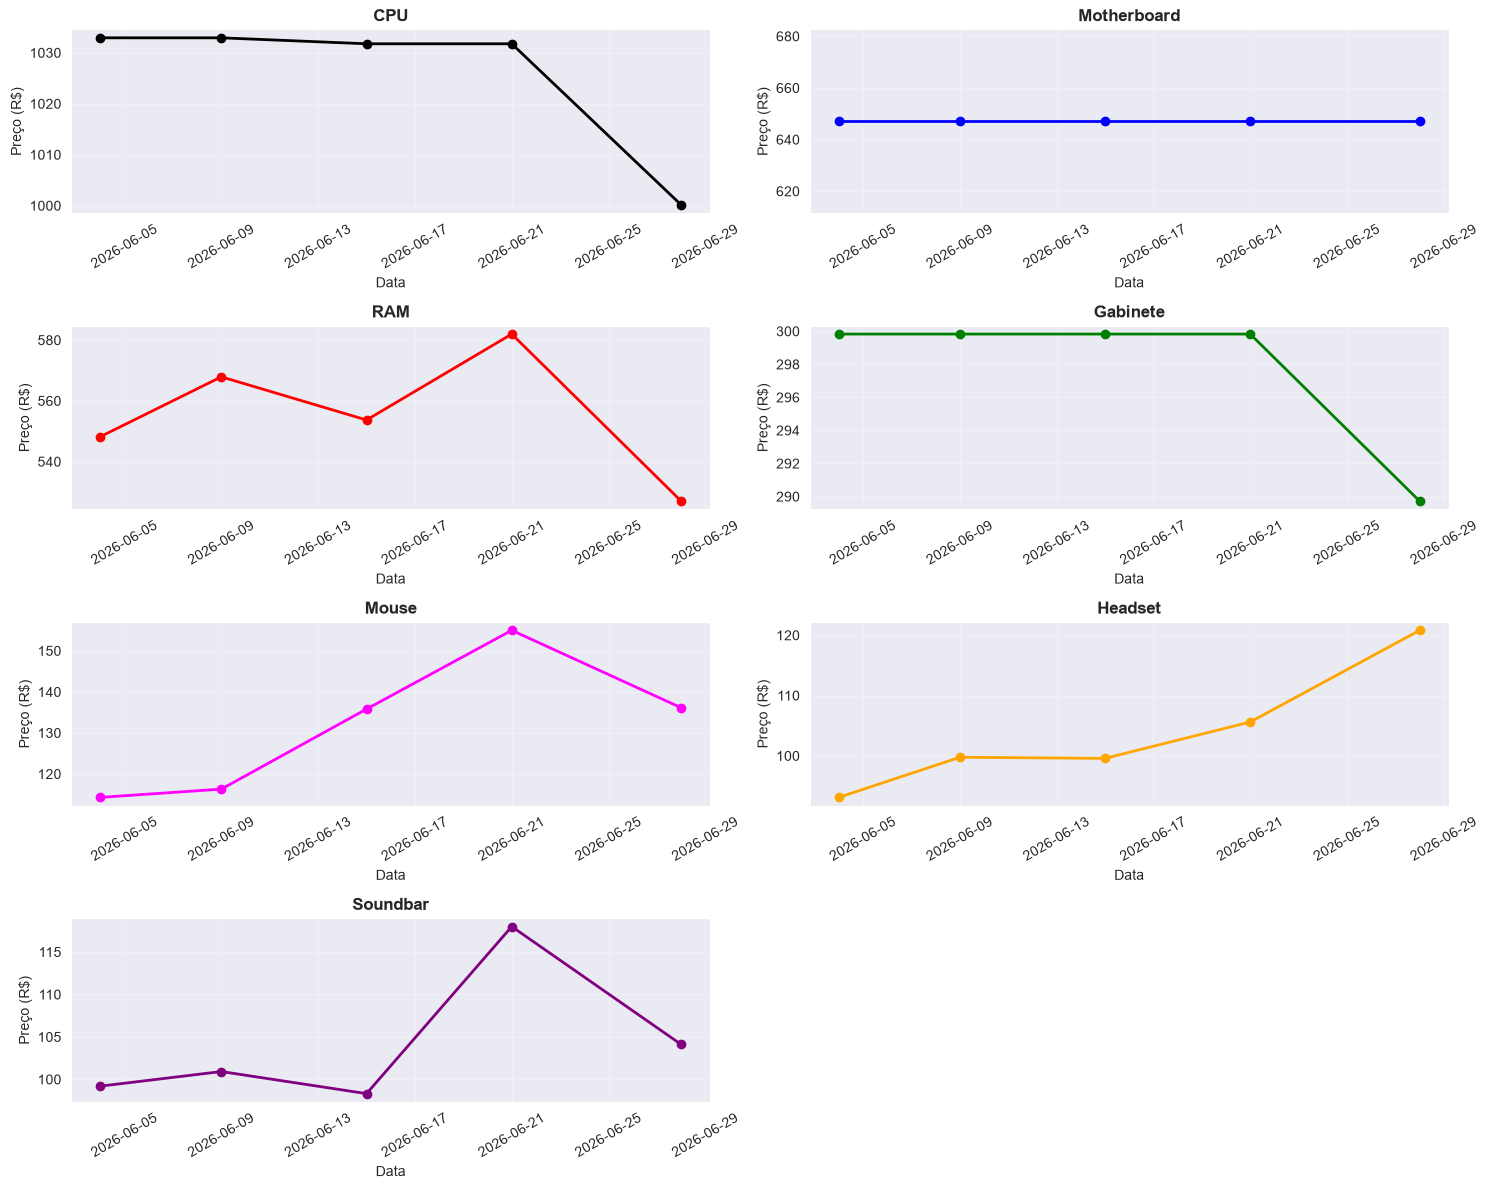

In [ ]:
# Opção 2: Gráficos separados para cada item (subplots)
fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.flatten()

cores = ['black', 'blue', 'red', 'green', 'magenta', 'orange', 'darkviolet', 'firebrick']

for idx, (item, df_item) in enumerate(df_itens.items()):
    if idx < len(axes):
        cor = cores[idx % len(cores)]

        axes[idx].plot(df_item['Data'], df_item['Preco'], 
                       marker='o', 
                       linewidth=2, 
                       markersize=6,
                       color=cor)
        axes[idx].set_title(f'{item}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Data', fontsize=10)
        axes[idx].set_ylabel('Preço (R$)', fontsize=10)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=30)

# Remover subplots vazios (se houver menos de 8 itens)
for idx in range(len(df_itens), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()

plt.savefig('plots/pcgamer_prices.png', dpi=300)

plt.show()

## Versão com valor médio

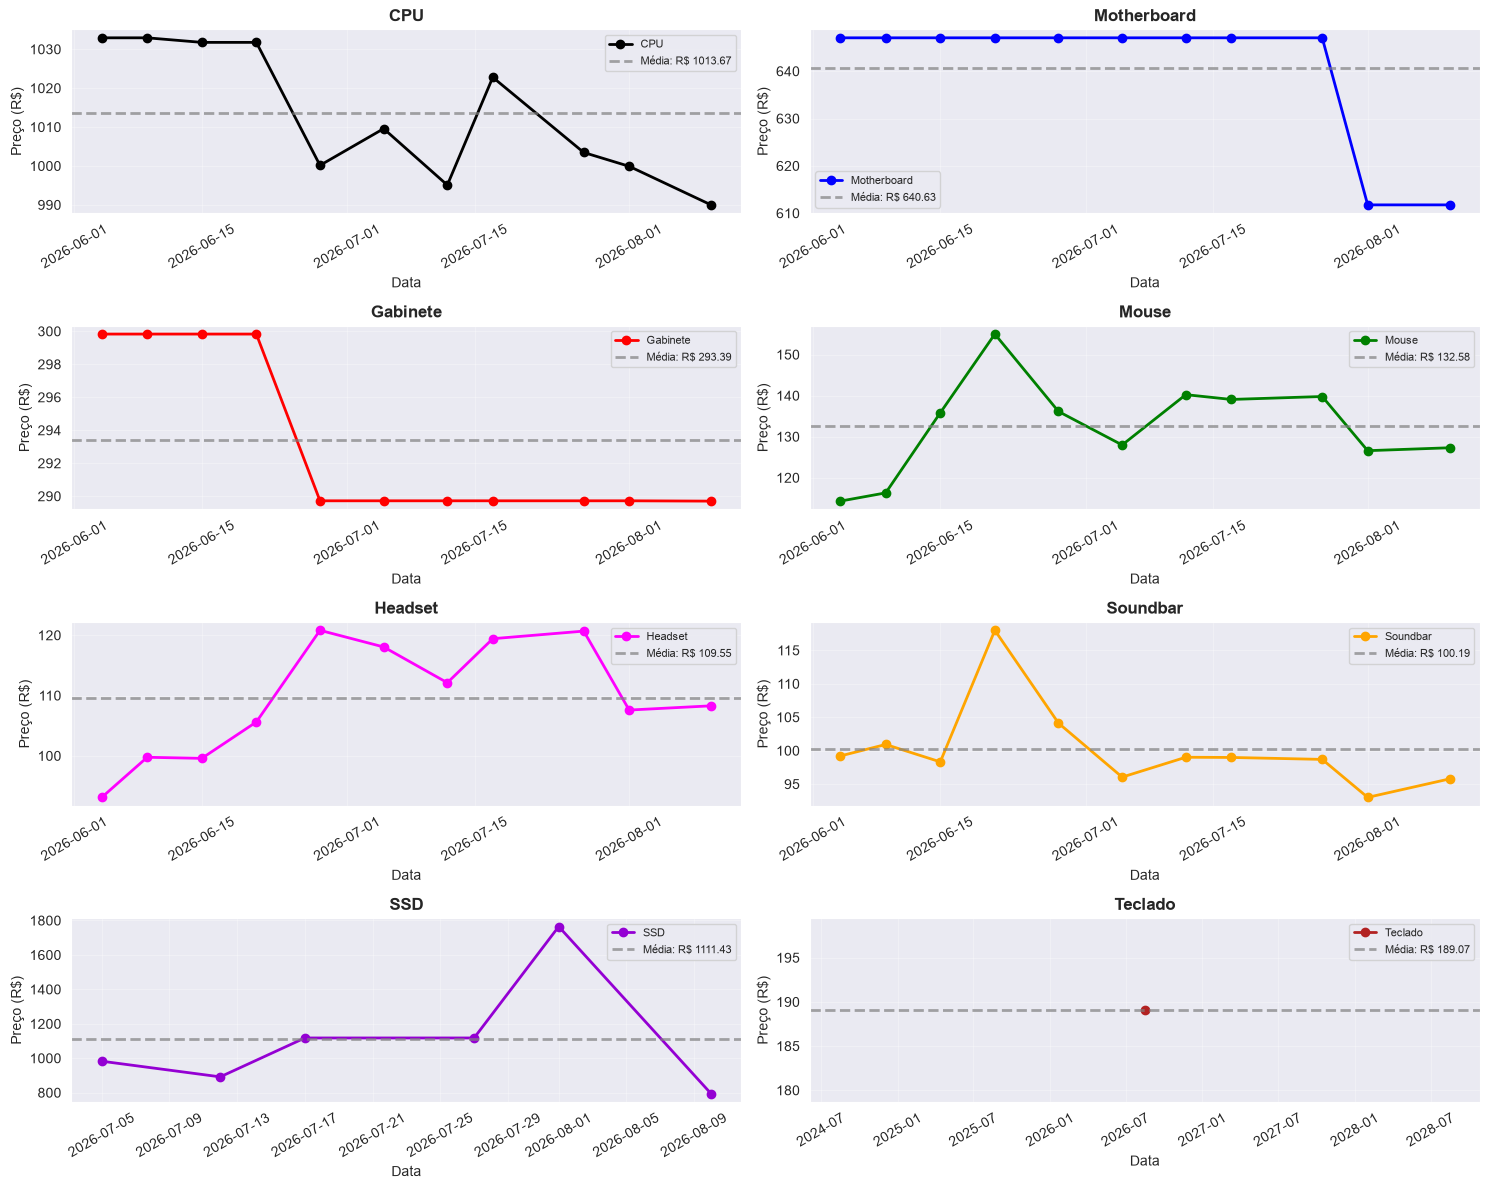

In [28]:
# Ler os dados (assumindo que df_itens já foi criado)
fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.flatten()

cores = ['black', 'blue', 'red', 'green', 'magenta', 'orange', 'darkviolet', 'firebrick']

for idx, (item, df_item) in enumerate(df_itens.items()):
    if idx < len(axes):
        cor = cores[idx % len(cores)]
        
        # Calcular o valor médio do preço para este item
        valor_medio = df_item['Preco'].mean()
        
        # Plotar os dados
        axes[idx].plot(df_item['Data'], df_item['Preco'], 
                       marker='o', 
                       linewidth=2, 
                       markersize=6,
                       color=cor,
                       label=f'{item}')
        
        # Adicionar a reta do valor médio (tracejada, preta)
        axes[idx].axhline(y=valor_medio, 
                          color='gray', 
                          linestyle='--', 
                          linewidth=2,
                          alpha=0.7,
                          label=f'Média: R$ {valor_medio:.2f}')
        
        axes[idx].set_title(f'{item}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Data', fontsize=10)
        axes[idx].set_ylabel('Preço (R$)', fontsize=10)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=30)
        axes[idx].legend(loc='best', fontsize=8)

# Remover subplots vazios (se houver menos de 8 itens)
for idx in range(len(df_itens), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()

# Salvar a figura
#plt.savefig('plots/pcgamer_prices.png', dpi=300)

plt.show()